### Dependencies

In [1]:
import pandas as pd
import matplotlib 
import matplotlib.pyplot as plt
%matplotlib inline

### Datasets exploration

In [ ]:
df_conversations = pd.read_parquet("conversations.parquet")
df_reactions = pd.read_parquet("reactions.parquet")
df_votes = pd.read_parquet("votes.parquet")

The code bellow was used to divide the conversations dataset into 10 subdatasets, for computers with lower capacities

In [ ]:
# DO NOT EXECUTE

for i in range(9):
    df_conversations[50000*i:50000*(i+1)].to_parquet(f"conversations_{i}.parquet")
df_conversations[50000*9:].to_parquet(f"conversations_{9}.parquet")

In [30]:
df_conversations.head()

,id,timestamp,model_a_name,model_b_name,conversation_a,conversation_b,conv_turns,conversation_pair_id,conv_a_id,conv_b_id,...,categories,languages,total_conv_a_output_tokens,total_conv_b_output_tokens,model_a_total_params,model_b_total_params,model_a_active_params,model_b_active_params,total_conv_a_kwh,total_conv_b_kwh
0,1562219,2026-03-06 19:37:04.399632,gemini-3.1-pro-preview,claude-4-6-sonnet,[{'content': 'Comment protéger les métiers art...,[{'content': 'Comment protéger les métiers art...,1,14edd982fc504dbe9835702fa2127ea5-1b4887d008ba4...,14edd982fc504dbe9835702fa2127ea5,1b4887d008ba47ac8ecba23600dcb4cf,...,"[Arts, Law & Justice, Business & Economics & F...",[fr],1596,1000,750.0,440.0,45.0,137.0,0.006846,0.003931
1,1562216,2026-03-06 19:35:14.874855,DeepSeek-V3.2,mistral-large-2512,[{'content': 'Cet extrait de L'Amant de Margue...,[{'content': 'Cet extrait de L'Amant de Margue...,1,dbe0a97393c944d7bbc0a2c8ed41fc2c-e9c80e780cc04...,dbe0a97393c944d7bbc0a2c8ed41fc2c,e9c80e780cc04a7799188076bebba660,...,"[Education, Arts, Culture & Cultural geography]",[fr],1829,2059,685.0,675.0,37.0,41.0,0.007277,0.008512
2,1553428,2026-03-05 11:04:09.160544,gpt-5-mini,Apertus-70B-Instruct-2509,[{'content': 'Quelle est la capitale de la Fra...,[{'content': 'Quelle est la capitale de la Fra...,1,8100c7848ee14997bc6248bc76bb8ff9-3afec45a9a374...,8100c7848ee14997bc6248bc76bb8ff9,3afec45a9a374ddbb7ca0652c50b8e0b,...,[Natural Science & Formal Science & Technology...,[fr],0,0,47.0,70.0,47.0,70.0,0.000000,0.000000
3,1562222,2026-03-06 19:37:42.727688,gemma-3-27b,qwen3-coder-next,[{'content': 'Ecrit moi un roman très très trè...,[{'content': 'Ecrit moi un roman très très trè...,0,4246bbb60ba9498eba23fd22ca443434-b55bf215f4ac4...,4246bbb60ba9498eba23fd22ca443434,b55bf215f4ac4494a0baf94952762be5,...,"[Entertainment & Travel & Hobby, Arts, Other]",[fr],0,0,27.0,80.0,27.0,3.0,0.000000,0.000000
4,1584150,2026-03-11 12:37:45.876836,Apertus-70B-Instruct-2509,mistral-medium-2508,[{'content': 'Tu es scientifiques en sciences ...,[{'content': 'Tu es scientifiques en sciences ...,1,58250d72e17945dfb26fa3c266f1e08b-857baa84a5554...,58250d72e17945dfb26fa3c266f1e08b,857baa84a5554d788cc5a8d29427cde9,...,"[Arts, Education, Culture & Cultural geography]",[fr],674,2206,70.0,123.0,70.0,123.0,0.000443,0.002018


We can take a look at the missing values in the datasets

In [31]:
nan_per_column = df_conversations.isnull().sum()
print(nan_per_column)

id                                 0
timestamp                          0
model_a_name                       0
model_b_name                       0
conversation_a                     0
conversation_b                     0
conv_turns                         0
conversation_pair_id               0
conv_a_id                          0
conv_b_id                          0
session_hash                       0
visitor_id                         0
model_pair_name                    0
opening_msg                        0
system_prompt_a               358813
system_prompt_b               358828
mode                           35489
custom_models_selection       428540
short_summary                      0
keywords                           0
categories                         0
languages                          0
total_conv_a_output_tokens         0
total_conv_b_output_tokens         0
model_a_total_params           44108
model_b_total_params           44143
model_a_active_params          44108
m

In [32]:
nan_per_column = df_reactions.isnull().sum()
print(nan_per_column)

id                               0
timestamp                        0
model_a_name                     0
model_b_name                     0
refers_to_model                  0
msg_index                        0
opening_msg                      0
conversation_a                   0
conversation_b                   0
model_pos                        0
conv_turns                       0
conversation_pair_id             0
conv_a_id                        0
conv_b_id                        0
refers_to_conv_id                0
session_hash                     0
visitor_id                       0
response_content                 0
question_content                 0
liked                            0
disliked                         0
comment                        877
useful                         516
creative                       516
complete                         0
clear_formatting               516
incorrect                      516
superficial                    516
instructions_not_fol

In [25]:
df_reactions_missing = df_reactions[df_reactions[["comment", "useful", "creative", "clear_formatting", "incorrect", "superficial", "instructions_not_followed"]].isna().any(axis=1)]
df_reactions_missing["complete"].value_counts()

complete
False    877
Name: count, dtype: int64

In [33]:
nan_per_column = df_votes.isnull().sum()
print(nan_per_column)

id                                       0
timestamp                                0
model_a_name                             0
model_b_name                             0
model_pair_name                          0
chosen_model_name                    52566
opening_msg                              0
both_equal                           13622
conversation_a                           0
conversation_b                           0
conv_turns                               0
selected_category                   146934
is_unedited_prompt                       0
conversation_pair_id                     0
session_hash                             0
visitor_id                               0
conv_comments_a                          0
conv_comments_b                          0
conv_useful_a                            0
conv_useful_b                            0
conv_creative_a                          0
conv_creative_b                          0
conv_clear_formatting_a                  0
conv_clear_

We can observe that most columns in the datasets are completely clean. The ones with lots of missing values are often just precisions about the models or the prompts used, or optional parameters. Only the columns with a few values missing in the reactions dataset seem to lack informations that are truly relevant in this study. The columns ["comment", "useful", "creative", "clear_formatting", "incorrect", "superficial", "instructions_not_followed"] have 877 missing values in total. It's probably due to the fact the user didn't respond because the given text was incomplete.

## Exercice 1.2

To study the selection bias of the voters, we can look at the conversations that are rated and explore their specificities.

In [3]:
df_conversations["present_in_small"] = df_conversations["id"].isin(df_votes["id"])

We can begin by studying the most rated categories. For each category, we can compute the proportion of instances that were rated :

In [4]:
df_conversations_categories = df_conversations.explode("categories")
group_categories = df_conversations_categories[df_conversations_categories["present_in_small"]]["categories"]
voted_categories = group_categories.value_counts()
total_categories = df_conversations_categories["categories"].value_counts()
for name in voted_categories.index:
    print(f"{name} : {voted_categories[name]/total_categories[name]} (total : {total_categories[name]})")

Natural Science & Formal Science & Technology : 0.15107066440351857 (total : 180869)
Education : 0.11634089443916444 (total : 150463)
Business & Economics & Finance : 0.15635606137587643 (total : 98410)
Society & Social Issues & Human Rights : 0.20784296881711192 (total : 69846)
Entertainment & Travel & Hobby : 0.1715552174612695 (total : 68357)
Politics & Government : 0.1416861649935844 (total : 66245)
Culture & Cultural geography : 0.15496203662349264 (total : 55975)
Personal Development & Human Resources & Career : 0.18840808948141452 (total : 44255)
Arts : 0.13446551828836306 (total : 49403)
Law & Justice : 0.1600877817995269 (total : 35087)
Daily Life & Home & Lifestyle : 0.19291506615450277 (total : 28116)
Health & Wellness & Medicine : 0.15491833476605674 (total : 32572)
Food & Drink & Cooking : 0.19940826004134074 (total : 24673)
Other : 0.1148728487027999 (total : 38930)
Environment : 0.10728703784380354 (total : 34431)
Shopping & Commodity : 0.18852368912828404 (total : 18194

In [5]:
# Keeping only the relevant categories to compute statistics (those with more than 100 instances in the conversations dataset)
voted_categories = voted_categories[total_categories > 100]
total_categories = total_categories[total_categories > 100]
ratio = voted_categories/total_categories

print(f"Max : {max(ratio)}")
print(f"Min : {min(ratio)}")
print(f"Mean : {(ratio).mean()}")
print(f"Standard deviation : {(ratio).std()}")

Max : 0.20784296881711192
Min : 0.10728703784380354
Mean : 0.1571467397539152
Standard deviation : 0.028742986173513296


Apart from the last topics which are not enough present in the conversations dataset to conclude, we can see that some topics are more frequently rated than others. For example, about 20% topics on Society & Social Issues & Human Rights are rated whereas only about 10% on Environment are - that's two times less - . We should be aware that this bias is present in the dataset. However, most topics are rated on 15% of instances, with a relatively low standard deviation.

The same kind of statistics can be observed for the most rated conversations depending on conv_turns, the number of dialogues in a conversation.

In [6]:
group_conv_turns = df_conversations[df_conversations["present_in_small"]]["conv_turns"]
voted_conv_turns = group_conv_turns.value_counts()
total_conv_turns = df_conversations["conv_turns"].value_counts()
for name in voted_conv_turns.index:
    print(f"{name} : {voted_conv_turns[name]/total_conv_turns[name]} (total : {total_conv_turns[name]})")

1 : 0.134384261923741 (total : 324919)
0 : 0.17441697527774996 (total : 49955)
2 : 0.15119225037257825 (total : 53680)
3 : 0.15401236118788 (total : 19901)
4 : 0.1573748902546093 (total : 9112)
5 : 0.1344689378757515 (total : 4990)
6 : 0.1287163343826513 (total : 2859)
7 : 0.1266560678325384 (total : 1887)
8 : 0.13000817661488143 (total : 1223)
9 : 0.1322314049586777 (total : 847)
10 : 0.12941176470588237 (total : 595)
11 : 0.11791383219954649 (total : 441)
12 : 0.11641791044776119 (total : 335)
13 : 0.0989010989010989 (total : 273)
15 : 0.10050251256281408 (total : 199)
16 : 0.14634146341463414 (total : 123)
14 : 0.09183673469387756 (total : 196)
17 : 0.09701492537313433 (total : 134)
20 : 0.14705882352941177 (total : 68)
19 : 0.07228915662650602 (total : 83)
18 : 0.07407407407407407 (total : 81)
28 : 0.1875 (total : 16)
24 : 0.08571428571428572 (total : 35)
35 : 0.2727272727272727 (total : 11)
34 : 0.1 (total : 10)
29 : 0.058823529411764705 (total : 17)
48 : 0.2 (total : 5)
31 : 0.06

In [7]:
voted_conv_turns = voted_conv_turns[total_conv_turns > 100]
total_conv_turns = total_conv_turns[total_conv_turns > 100]
ratio = voted_conv_turns/total_conv_turns
print(f"Max : {max(ratio)}")
print(f"Min : {min(ratio)}")
print(f"Mean : {(ratio).mean()}")
print(f"Standard deviation : {(ratio).std()}")

Max : 0.17441697527774996
Min : 0.09183673469387756
Mean : 0.12898899460998933
Standard deviation : 0.02270811258437638


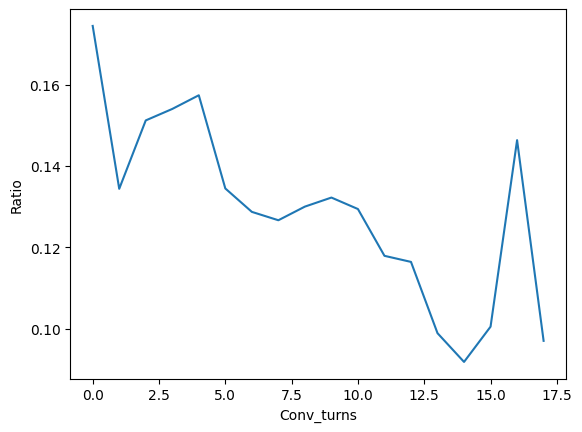

In [8]:
ratio = (voted_conv_turns / total_conv_turns).sort_index(ascending=False)
plt.xlabel("Conv_turns")
plt.ylabel("Ratio")
plt.plot(ratio)

We can see that conversations with more dialogues tend to be less rated (in general). So this feature of the dataset also introduces bias.

And finally, we can also assert if there's bias with respect to the number of tokens in the output :

In [33]:
group_conv_a_total_output_tokens = df_conversations[df_conversations["present_in_small"]]["total_conv_a_output_tokens"]
voted_conv_a_total_output_tokens = group_conv_a_total_output_tokens.value_counts()
total_conv_a_total_output_tokens = df_conversations["total_conv_a_output_tokens"].value_counts()
for name in voted_conv_a_total_output_tokens.index:
    print(f"{name} : {voted_conv_a_total_output_tokens[name]/total_conv_a_total_output_tokens[name]} (total : {total_conv_a_total_output_tokens[name]})")

0 : 0.13927417822534677 (total : 63156)
11 : 0.18386714116251482 (total : 843)
449 : 0.303125 (total : 320)
418 : 0.2908496732026144 (total : 306)
513 : 0.27129337539432175 (total : 317)
512 : 0.273015873015873 (total : 315)
641 : 0.29328621908127206 (total : 283)
451 : 0.2647058823529412 (total : 306)
611 : 0.2709030100334448 (total : 299)
597 : 0.25 (total : 312)
493 : 0.24522292993630573 (total : 314)
495 : 0.24600638977635783 (total : 313)
467 : 0.2576271186440678 (total : 295)
385 : 0.2245508982035928 (total : 334)
392 : 0.2516778523489933 (total : 298)
442 : 0.2525597269624573 (total : 293)
582 : 0.25524475524475526 (total : 286)
492 : 0.24829931972789115 (total : 294)
672 : 0.22955974842767296 (total : 318)
563 : 0.2589928057553957 (total : 278)
468 : 0.22929936305732485 (total : 314)
642 : 0.27169811320754716 (total : 265)
494 : 0.23529411764705882 (total : 306)
516 : 0.24573378839590443 (total : 293)
676 : 0.21492537313432836 (total : 335)
445 : 0.2099125364431487 (total : 343

In [34]:
voted_conv_a_total_output_tokens = voted_conv_a_total_output_tokens[total_conv_a_total_output_tokens > 100]
total_conv_a_total_output_tokens = total_conv_a_total_output_tokens[total_conv_a_total_output_tokens > 100]
ratio = voted_conv_a_total_output_tokens/total_conv_a_total_output_tokens
print(f"Max : {max(ratio)}")
print(f"Min : {min(ratio)}")
print(f"Mean : {(ratio).mean()}")
print(f"Standard deviation : {(ratio).std()}")

Max : 0.303125
Min : 0.025
Mean : 0.1562364959474054
Standard deviation : 0.04645406665362206


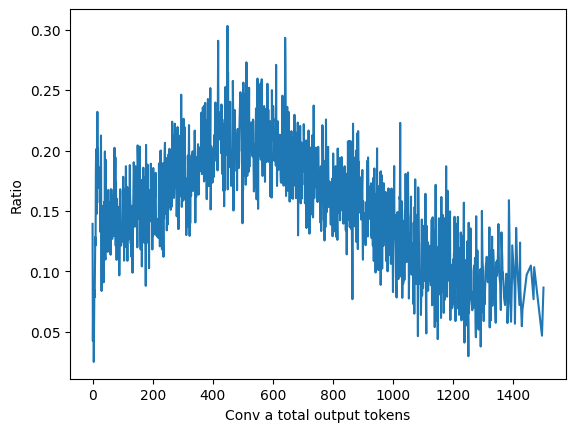

In [12]:
ratio = (voted_conv_a_total_output_tokens / total_conv_a_total_output_tokens).sort_index(ascending=False)
plt.xlabel("Conv a total output tokens")
plt.ylabel("Ratio")
plt.plot(ratio)


As we can see on the plot, the number of token in the output can also be seen as a source of bias : the proportion of responses follows (with noise) the total output tokens for conversation a, with a pick around 500-600 tokens.